In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy as scp
from scipy import optimize
%matplotlib inline

In [42]:
dados = {
    "Evento": [
        "1500 m", "1500 m (indoor)", "One mile", "3000 m", "3000 m (indoor)", 
        "Two miles", "Two miles (indoor)", "5000 m", "5000 m (indoor)", 
        "10 000 m", "5 km", "10 km", "Half marathon", "30 km", "Marathon"
    ],
    "Distancia_m": [
        1500.0, 1500.0, 1609.34, 3000.0, 3000.0, 
        3218.68, 3218.68, 5000.0, 5000.0, 
        10000.0, 5000.0, 10000.0, 21097.5, 30000.0, 42195.0
    ],
    "Tempo_s": [
        213.0, 216.0, 230.0, 448.0, 449.0, 
        488.0, 487.0, 767.0, 776.0, 
        1609.0, 791.0, 1691.0, 3565.0, 5233.0, 7299.0
    ],
    "Velocidade_ms": [
        7.04, 6.94, 6.98, 6.70, 6.68, 
        6.60, 6.60, 6.52, 6.45, 
        6.21, 6.32, 5.91, 5.92, 5.73, 5.78
    ]
}
df = pd.DataFrame(dados)

df.rename(columns={"Tempo_s":"Tempo_h", "Velocidade_ms":"Velocidade_kmh","Distancia_m":"Distancia_km"},inplace=True)

df['Tempo_h'] = df['Tempo_h'] / 3600 # s → h
df['Distancia_km'] = df['Distancia_km'] / 1000 # m → km
df['Velocidade_kmh'] = df['Velocidade_kmh'] * 3.6 # m/s → km/h

tempos = df['Tempo_h'].values
velocidades = df['Velocidade_kmh'].values
distancias = df['Distancia_km'].values

In [43]:
def modelo_sigmoide(T, A, k, t0, V_base):
    return V_base + A / (1.0 + np.exp(k * (T - t0)))

def modelo_potencia(T, S, E):
    return S * T**(E - 1.0)

def modelo_perfil(T, a, alpha, gamma):
    return (a * T**alpha) / (T**alpha + np.abs(gamma)**alpha) + a

In [44]:
# 3. Chutes Iniciais e Fitting
V_max = np.max(velocidades)
V_min = np.min(velocidades)
Delta_V = V_max - V_min

p0_sig = [Delta_V, 0.005, 10.0, V_min]
p0_pow = [10.0, 0.94]
p0_perfil = [V_max, -0.5, 10.0]

# --- ADIÇÃO DOS LIMITES (BOUNDS) ---
# Formato: bounds=([limites_inferiores], [limites_superiores])

# Sigmoide: [Amplitude > 0, k > 0, t0 > 0, V_base > 0]
bounds_sig = ([0.0, 0.0, 0.0, 0.0], 
              [1000.0, 1000.0, 1000.0, 1000.0])

# Perfil (Imagem): [a > 0, alpha < 0, gamma > 0]
# Alpha precisa ser negativo para a curva cair! Limitamos o teto dele a 0.
bounds_perfil = ([0.0, -10.0, 0.0], 
                 [2000.0, 0000.0, 2000.0])

In [ ]:
popt_sig, _ = optimize.curve_fit(modelo_sigmoide, tempos, velocidades, p0=p0_sig, bounds=bounds_sig, maxfev=10000)
popt_pow, _ = optimize.curve_fit(modelo_potencia, tempos, velocidades, p0=p0_pow, maxfev=10000)
popt_perfil, _ = optimize.curve_fit(modelo_perfil, tempos, velocidades, p0=p0_perfil, bounds=bounds_perfil, maxfev=10000)

erro_sig = abs(velocidades - modelo_sigmoide(tempos, *popt_sig))
erro_pow = abs(velocidades - modelo_potencia(tempos, *popt_pow))
erro_perfil = abs(velocidades - modelo_perfil(tempos, *popt_perfil))

C:\Users\gabriel.vernizi\AppData\Local\Temp\ipykernel_21904\664207798.py:5: RuntimeWarning: divide by zero encountered in power
  return S * T**(E - 1.0)
C:\Users\gabriel.vernizi\AppData\Local\Temp\ipykernel_21904\664207798.py:8: RuntimeWarning: divide by zero encountered in power
  return (a * T**alpha) / (T**alpha + np.abs(gamma)**alpha) + a
C:\Users\gabriel.vernizi\AppData\Local\Temp\ipykernel_21904\664207798.py:8: RuntimeWarning: invalid value encountered in divide
  return (a * T**alpha) / (T**alpha + np.abs(gamma)**alpha) + a


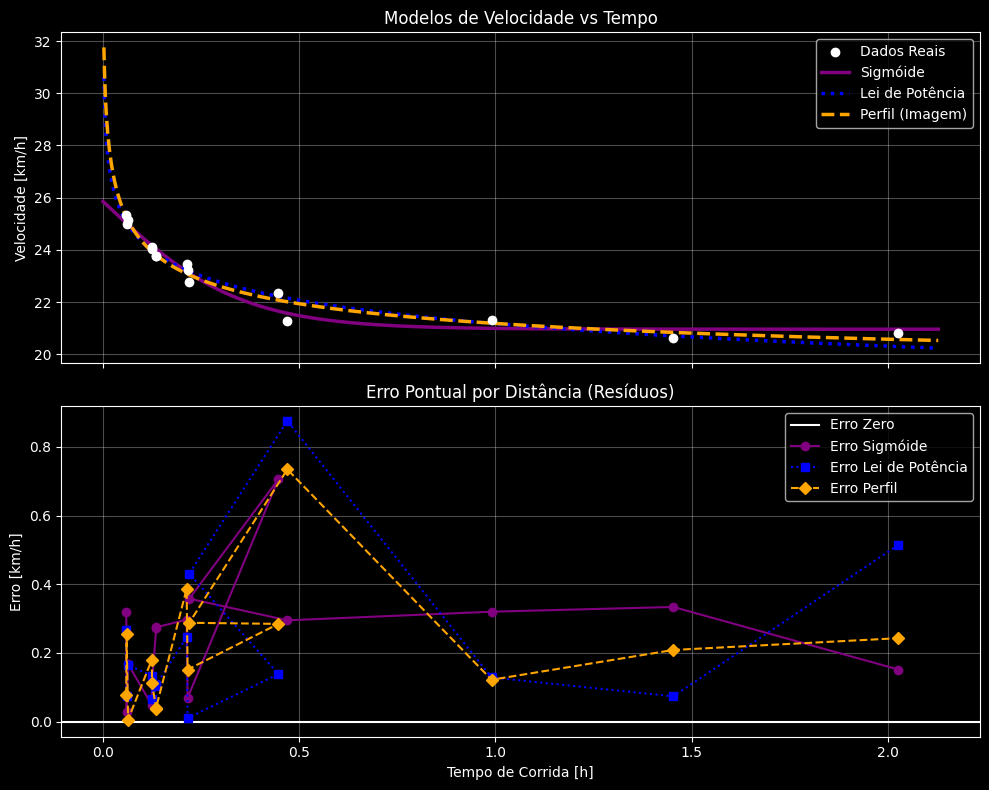

In [46]:
plt.style.use('dark_background') # Para manter o estilo escuro do Pluto.jl (opcional)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

T_plot = np.linspace(0, np.max(tempos) * 1.05, 1000)
ax1.scatter(tempos, velocidades, color='white', label='Dados Reais', zorder=5)
ax1.plot(T_plot, modelo_sigmoide(T_plot, *popt_sig), color='purple', lw=2.5, label='Sigmóide')
ax1.plot(T_plot, modelo_potencia(T_plot, *popt_pow), color='blue', lw=2.5, ls=':', label='Lei de Potência')
ax1.plot(T_plot, modelo_perfil(T_plot, *popt_perfil), color='orange', lw=2.5, ls='--', label='Perfil (Imagem)')
ax1.set_ylabel('Velocidade [km/h]')
ax1.set_title('Modelos de Velocidade vs Tempo')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Erros Pontuais
ax2.axhline(0, color='white', lw=1.5, label='Erro Zero')
ax2.plot(tempos, erro_sig, color='purple', marker='o', lw=1.5, label='Erro Sigmóide')
ax2.plot(tempos, erro_pow, color='blue', marker='s', ls=':', lw=1.5, label='Erro Lei de Potência')
ax2.plot(tempos, erro_perfil, color='orange', marker='D', ls='--', lw=1.5, label='Erro Perfil')
ax2.set_xlabel('Tempo de Corrida [h]')
ax2.set_ylabel('Erro [km/h]')
ax2.set_title('Erro Pontual por Distância (Resíduos)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
def prever_tempo_powerlaw(D, popt):
    S, E = popt
    return (D / S)**(1.0 / E)

def prever_tempo_numerico(modelo, popt, D_alvo, T_min=1.0, T_max=200000.0):
    # Função objetivo para o SciPy encontrar a raiz: f(T) = 0
    def funcao_objetivo(T):
        return modelo(T, *popt) * T - D_alvo
    
    # Utilizando o método da bissecção nativo do SciPy
    return optimize.bisect(funcao_objetivo, T_min, T_max, xtol=1e-3)

def formatar_tempo(segundos_totais):
    seg = int(round(segundos_totais))
    h = seg // 3600
    m = (seg % 3600) // 60
    s = seg % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

# Exemplo de Uso:
D_teste = 21097.5 # Meia Maratona

T_pow = prever_tempo_powerlaw(D_teste, popt_pow)
T_sig = prever_tempo_numerico(modelo_sigmoide, popt_sig, D_teste)
T_perfil = prever_tempo_numerico(modelo_perfil, popt_perfil, D_teste)

print(f"\n--- Previsão de Tempo para D = {D_teste} metros ---")
print(f"Lei de Potência : {T_pow:.1f}s \t-> {formatar_tempo(T_pow)}")
print(f"Sigmóide        : {T_sig:.1f}s \t-> {formatar_tempo(T_sig)}")
print(f"Perfil (Imagem) : {T_perfil:.1f}s \t-> {formatar_tempo(T_perfil)}")


--- Previsão de Tempo para D = 21097.5 metros ---
Lei de Potência : 1547.3s 	-> 00:25:47
Sigmóide        : 1006.6s 	-> 00:16:47
Perfil (Imagem) : 1125.6s 	-> 00:18:46


C:\Users\gabriel.vernizi\AppData\Local\Temp\ipykernel_21904\664207798.py:2: RuntimeWarning: overflow encountered in exp
  return V_base + A / (1.0 + np.exp(k * (T - t0)))
